# Exploratory Data Analysis
## Difference-in-Differences Analysis of Minimum Wage Policies and Teen Employment

This notebook provides an initial exploration of the county-level minimum wage dataset used in Chapter 16 of the CausalML Book.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Loading the data

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/CausalAIBook/MetricsMLNotebooks/main/data/minwage_data.csv",
                   index_col=0)

In [4]:
data.head()

,countyreal,state_name,year,FIPS,emp0A01_BS,quarter,censusdiv,pop,annual_avg_pay,state_mw,fed_mw,treated,G,lemp,lpop,lavg_pay,region,ever_treated,id
1,2013,Alaska,2001,2013,15,1,9,2459,22155,5.65,5.15,1,2001,2.708050,7.807510,10.005818,4,1,2013
2,2013,Alaska,2002,2013,17,1,9,2664,28447,5.65,5.15,1,2001,2.833213,7.887584,10.255798,4,1,2013
3,2013,Alaska,2003,2013,12,1,9,2715,30184,7.15,5.15,1,2001,2.484907,7.906547,10.315067,4,1,2013
4,2013,Alaska,2004,2013,13,1,9,2677,27557,7.15,5.15,1,2001,2.564949,7.892452,10.224012,4,1,2013
5,2013,Alaska,2005,2013,11,1,9,2646,30396,7.15,5.15,1,2001,2.397895,7.880804,10.322066,4,1,2013


## Data Overview

We inspect the dataset structure, dimensions, variable types, and missing values.

In [23]:
data.shape
data.info()
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 18851 entries, 1 to 18851
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   countyreal      18851 non-null  int64  
 1   state_name      18851 non-null  object 
 2   year            18851 non-null  int64  
 3   FIPS            18851 non-null  int64  
 4   emp0A01_BS      18851 non-null  int64  
 5   quarter         18851 non-null  int64  
 6   censusdiv       18851 non-null  int64  
 7   pop             18851 non-null  int64  
 8   annual_avg_pay  18851 non-null  int64  
 9   state_mw        3149 non-null   float64
 10  fed_mw          18851 non-null  float64
 11  treated         18851 non-null  int64  
 12  G               18851 non-null  int64  
 13  lemp            18851 non-null  float64
 14  lpop            18851 non-null  float64
 15  lavg_pay        18851 non-null  float64
 16  region          18851 non-null  int64  
 17  ever_treated    18851 non-null  int6

,0
countyreal,0
state_name,0
year,0
FIPS,0
emp0A01_BS,0
quarter,0
censusdiv,0
pop,0
annual_avg_pay,0
state_mw,15702


The dataset contains no missing values in the main outcome, treatment, and control variables used in the analysis.

The variable `state_mw` contains many missing observations, likely corresponding to counties where the federal minimum wage applies and no separate state minimum wage is recorded.

## Descriptive Statistics

In [27]:
data[["lemp","pop","annual_avg_pay"]].describe()

,lemp,pop,annual_avg_pay
count,18851.000000,1.885100e+04,18851.000000
mean,5.848668,9.809654e+04,28686.146199
std,1.606732,3.164184e+05,6749.989978
min,1.098612,6.000000e+02,13298.000000
25%,4.762174,1.093250e+04,24268.500000
50%,5.780744,2.613200e+04,27479.000000
75%,6.813445,6.692400e+04,31536.000000
max,11.709191,9.917331e+06,100908.000000


The dataset contains 18,851 county-year observations from 2001–2007. Teen employment, population, and average annual pay exhibit substantial variation across counties. Population is particularly dispersed, indicating the presence of both very small and very large counties. This heterogeneity highlights the importance of accounting for differences across counties when evaluating the impact of minimum wage policies on teen employment.

## Outcome Variable Distribution

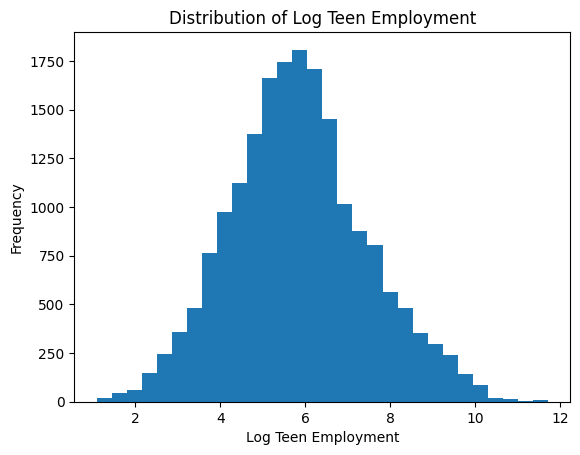

In [28]:
plt.hist(data["lemp"], bins=30)
plt.title("Distribution of Log Teen Employment")
plt.xlabel("Log Teen Employment")
plt.ylabel("Frequency")
plt.show()

The distribution of log teen employment is approximately bell-shaped and relatively symmetric, with most observations concentrated between 4 and 8. The log transformation appears to reduce the influence of extreme values and produces a distribution that is well suited for regression-based analysis.


## Employment Trends:
### Plot 1: Average employment over time

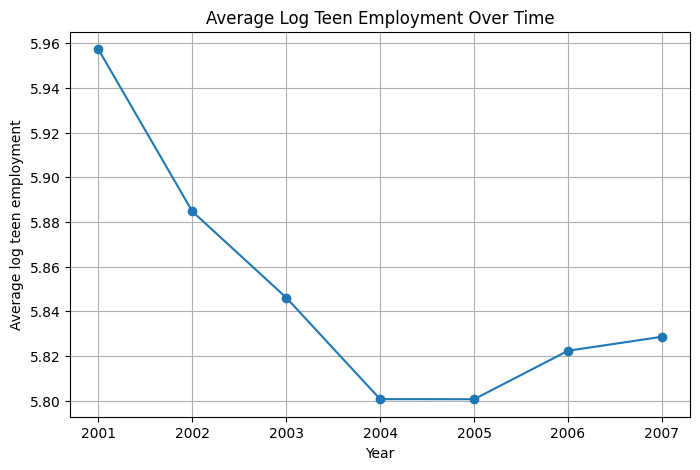

In [11]:
avg_emp_year = data.groupby("year")["lemp"].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_emp_year.index, avg_emp_year.values, marker="o")
plt.title("Average Log Teen Employment Over Time")
plt.xlabel("Year")
plt.ylabel("Average log teen employment")
plt.grid(True)
plt.show()

Average log teen employment declines steadily between 2001 and 2004, followed by a modest recovery through 2007. This pattern suggests that teen employment experienced important changes during the study period, highlighting the need for a causal analysis to determine whether minimum wage policies contributed to these trends or whether they were driven by broader economic factors.

### Plot 2 — Treated vs Control Employment Trends

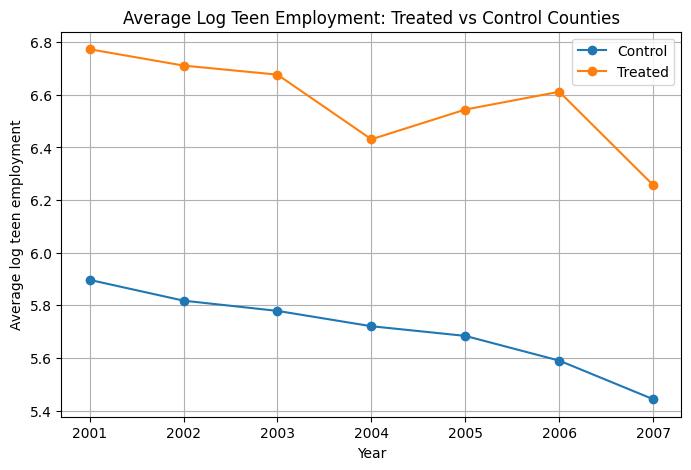

In [12]:
trend = data.groupby(["year", "treated"])["lemp"].mean().reset_index()

plt.figure(figsize=(8,5))

for group in trend["treated"].unique():
    subset = trend[trend["treated"] == group]
    label = "Treated" if group == 1 else "Control"
    plt.plot(subset["year"], subset["lemp"], marker="o", label=label)

plt.title("Average Log Teen Employment: Treated vs Control Counties")
plt.xlabel("Year")
plt.ylabel("Average log teen employment")
plt.legend()
plt.grid(True)
plt.show()


Treated counties consistently exhibit higher levels of teen employment than control counties throughout the study period. Both groups experience a decline in employment over time, although the patterns differ somewhat across years. While these differences suggest that treated and control counties may have distinct characteristics, the figure alone does not establish a causal effect of minimum wage policies and motivates the use of causal inference methods in the subsequent analysis.

## Treatment Assignment
###Plot 3 — number of treated observations over time:

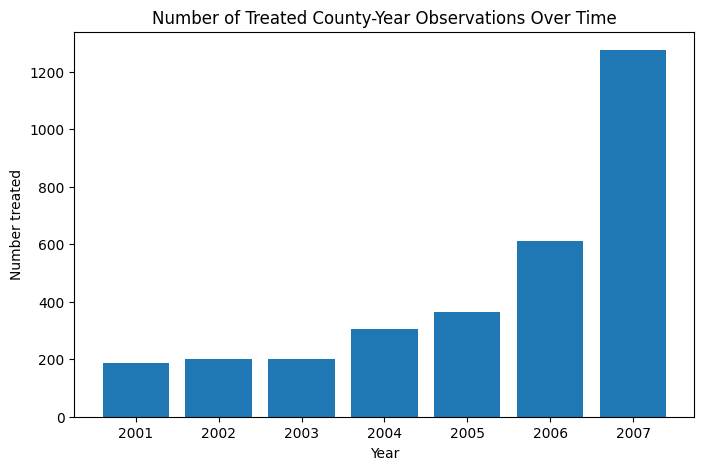

In [13]:
treated_counts = data.groupby("year")["treated"].sum()

plt.figure(figsize=(8,5))
plt.bar(treated_counts.index, treated_counts.values)
plt.title("Number of Treated County-Year Observations Over Time")
plt.xlabel("Year")
plt.ylabel("Number treated")
plt.show()

The number of treated county-year observations increases steadily throughout the sample period, with a particularly strong rise after 2004. This indicates that exposure to higher state minimum wages became more widespread over time. The variation in treatment status across years provides the policy changes necessary to investigate the relationship between minimum wage increases and teen employment outcomes.


### Population Characteristics

Before conducting causal analysis, it is useful to compare basic demographic characteristics of treated and untreated counties.

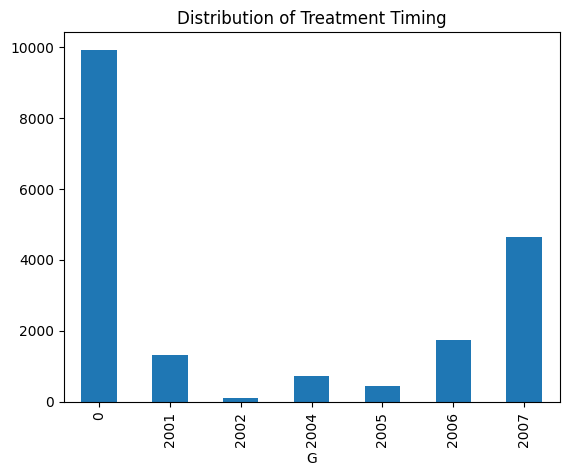

In [24]:
data["G"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Treatment Timing")
plt.show()

The treatment timing varies across counties, with a large number of counties never receiving treatment (`G = 0`) and others becoming treated in different years. This staggered adoption of minimum wage increases provides variation in both treatment status and treatment timing, which is valuable for evaluating the relationship between minimum wage policies and teen employment outcomes.